In [ ]:
# =========================================================
# AUTONOMOUS PREPROCESSING MULTI-AGENT SYSTEM
# WITH DEBUGGER AGENT
# =========================================================

import os
import io
import sys
import traceback
import warnings
import logging

import pandas as pd
import numpy as np

from typing import (TypedDict,List,Optional)
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI

from langgraph.graph import (StateGraph,END)

from rich.console import Console
from rich.panel import Panel
from rich.syntax import Syntax
from rich.table import Table
from rich import box

# =========================================================
# CONFIGURATION
# =========================================================

load_dotenv(".env")
gemini_api_key = os.getenv("GEMINI_API_KEY")
DATASET_PATH = "dataset.csv"
OUTPUT_DATASET = "Final_Dataset.csv"

# =========================================================
# LOGGING
# =========================================================

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logger = logging.getLogger(__name__)
warnings.filterwarnings("ignore")
console = Console()

# =========================================================
# LOAD DATASET
# =========================================================

df = pd.read_csv(DATASET_PATH)
console.print(
    "\n[bold green]"
    "Dataset Loaded Successfully"
    "[/bold green]\n"
)


# =========================================================
# DATASET PREVIEW
# =========================================================
preview_table = Table(
    title="Dataset Preview",
    box=box.DOUBLE_EDGE
)

for col in df.columns:
    preview_table.add_column(col)
for _, row in df.head().iterrows():
    preview_table.add_row(
        *[str(i) for i in row]
    )
console.print(preview_table)


# =========================================================
# LLM
# =========================================================

llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    temperature=0,
    google_api_key=os.getenv("GEMINI_API_KEY"),
)

# =========================================================
# PREPROCESSING TASKS
# =========================================================

PREPROCESSING_TASKS = [
    "Display dataset summary",
    "Print rows, columns and column names",
    "Identify numerical and categorical columns",
    "Handle missing values",
    "Handle outliers using IQR only for numeric columns",
    "Find duplicate rows"
]

Dataset Loaded Successfully

                        Dataset Preview                        
╔════════════╤═════════╤══════════╤═══════════════╤═══════════╗
║ date       │ sku     │ location │ quantity_sold │ inventory ║
╟────────────┼─────────┼──────────┼───────────────┼───────────╢
║ 2024-01-01 │ SKU_101 │ Chennai  │ 52.0          │ 120       ║
║ 2024-01-02 │ SKU_101 │ Chennai  │ 49.0          │ 115       ║
║ 2024-01-03 │ SKU_101 │ Chennai  │ nan           │ 110       ║
║ 2024-01-04 │ SKU_101 │ Chennai  │ 55.0          │ 105       ║
║ 2024-01-05 │ SKU_101 │ Chennai  │ 60.0          │ 100       ║
╚════════════╧═════════╧══════════╧═══════════════╧═══════════╝

In [12]:
# =========================================================
# STATE
# =========================================================

class PreprocessingState(TypedDict):
    df: pd.DataFrame
    tasks: List[str]
    task_index: int
    current_task: str
    generated_code: str
    preprocessing_output: str
    preprocessing_error: Optional[str]
    retry_count: int
    max_retries: int
    debug_history: List[str]
    last_error: str

In [13]:
# =========================================================
# PLANNER AGENT
# =========================================================

def planner_agent(state):
    task_index = state["task_index"]
    task = state["tasks"][task_index]
    console.print(

        f"\n[bold cyan]"
        f"PREPROCESSING TASK "
        f"{task_index + 1}"
        f"[/bold cyan]"
    )

    console.print(
        f"[yellow]{task}[/yellow]"
    )

    return {
        "current_task": task
    }

In [14]:
# =========================================================
# CODER AGENT
# =========================================================

def coder_agent(state):
    task = state["current_task"]
    prompt = f"""
You are an expert Python preprocessing engineer.

Rules:
1. Dataframe name is df
2. Use pandas and numpy only
3. Do NOT reload dataset
4. Return executable Python code only
5. Print meaningful output
6. Update df if preprocessing is applied

Task:
{task}
"""

    response = llm.invoke(prompt)
    code = response.content.strip()
    code = code.replace(
        "```python",
        ""
    )
    code = code.replace(
        "```",
        ""
    )
    console.print(

        "\n[bold green]"
        "GENERATED CODE"
        "[/bold green]\n"
    )
    syntax = Syntax(

        code,

        "python",

        theme="monokai"
    )
    console.print(syntax)
    return {
        "generated_code": code
    }

In [15]:
# =========================================================
# EXECUTOR AGENT
# =========================================================

def executor_agent(state):
    code = state["generated_code"]
    dataframe = state["df"]
    local_vars = {
        "df": dataframe.copy(),
        "pd": pd,
        "np": np
    }

    buffer = io.StringIO()
    try:
        sys.stdout = buffer
        exec(code, {}, local_vars)
        sys.stdout = sys.__stdout__
        updated_df = local_vars.get(
            "df",
            dataframe
        )
        output = buffer.getvalue()

        console.print(
            Panel(
                output if output else "Execution Completed",
                title="Execution Output",
                style="bold green"
            )
        )

        return {
            "df": updated_df,
            "preprocessing_output": output,
            "preprocessing_error": None,
            "last_error": ""
        }

    except Exception:
        sys.stdout = sys.__stdout__
        error_message = traceback.format_exc()
        console.print(
            Panel(
                error_message,
                title="Execution Failed",
                style="bold red"
            )
        )

        return {
            "preprocessing_error": error_message,
            "last_error": error_message
        }

In [16]:
# =========================================================
# DEBUGGER AGENT
# =========================================================

def debugger_agent(state):
    console.print(
        "\n[bold red]"
        "DEBUGGER AGENT ACTIVATED"
        "[/bold red]"
    )

    task = state["current_task"]

    original_code = state["generated_code"]

    error_message = state["last_error"]

    debug_prompt = f"""
You are a senior Python debugging engineer.

Task:
{task}

Original Code:
{original_code}

Execution Error:
{error_message}

Rules:
1. Fix the error
2. Preserve original preprocessing logic
3. Dataframe name must remain df
4. Use pandas and numpy only
5. Return ONLY executable Python code
6. Do not explain anything
7. Handle numeric-only operations correctly
"""

    response = llm.invoke(debug_prompt)

    fixed_code = response.content.strip()

    fixed_code = fixed_code.replace(
        "```python",
        ""
    )

    fixed_code = fixed_code.replace(
        "```",
        ""
    )

    console.print(

        "\n[bold yellow]"
        "FIXED CODE GENERATED"
        "[/bold yellow]\n"
    )

    syntax = Syntax(

        fixed_code,

        "python",

        theme="monokai"
    )

    console.print(syntax)

    debug_history = state["debug_history"]

    debug_history.append(error_message)

    return {

        "generated_code": fixed_code,

        "retry_count":
        state["retry_count"] + 1,

        "debug_history": debug_history
    }

In [17]:
# =========================================================
# EXECUTION ROUTER
# =========================================================

def execution_router(state):
    # SUCCESS
    if state["preprocessing_error"] is None:
        return "checker_agent"
    # MAX RETRIES REACHED
    if state["retry_count"] >= state["max_retries"]:
        return END

    # SEND TO DEBUGGER
    return "debugger_agent"

In [18]:
# =========================================================
# CHECKER AGENT
# =========================================================

def checker_agent(state):
    console.print(
        "\n[bold green]"
        "TASK COMPLETED SUCCESSFULLY"
        "[/bold green]"
    )

    return {}


# =========================================================
# NEXT TASK AGENT
# =========================================================
def next_task_agent(state):

    return {

        "task_index":
        state["task_index"] + 1,

        "retry_count": 0
    }


In [19]:
# =========================================================
# PREPROCESSING ROUTER
# =========================================================

def preprocessing_router(state):

    next_index = state["task_index"] + 1

    if next_index >= len(state["tasks"]):

        return END

    return "planner_agent"


# =========================================================
# BUILD GRAPH
# =========================================================

builder = StateGraph(
    PreprocessingState
)


# =========================================================
# ADD NODES
# =========================================================

builder.add_node(
    "planner_agent",
    planner_agent
)

builder.add_node(
    "coder_agent",
    coder_agent
)

builder.add_node(
    "executor_agent",
    executor_agent
)

builder.add_node(
    "debugger_agent",
    debugger_agent
)

builder.add_node(
    "checker_agent",
    checker_agent
)

builder.add_node(
    "next_task_agent",
    next_task_agent
)


# =========================================================
# ENTRY POINT
# =========================================================

builder.set_entry_point(
    "planner_agent"
)


# =========================================================
# MAIN FLOW
# =========================================================

builder.add_edge(
    "planner_agent",
    "coder_agent"
)

builder.add_edge(
    "coder_agent",
    "executor_agent"
)


# =========================================================
# EXECUTION ROUTING
# =========================================================

builder.add_conditional_edges(

    "executor_agent",

    execution_router,

    {

        "checker_agent":
        "checker_agent",

        "debugger_agent":
        "debugger_agent",

        END: END
    }
)


# =========================================================
# DEBUG LOOP
# =========================================================

builder.add_edge(
    "debugger_agent",
    "executor_agent"
)


# =========================================================
# CONTINUE TASKS
# =========================================================

builder.add_edge(
    "checker_agent",
    "next_task_agent"
)

builder.add_conditional_edges(

    "next_task_agent",

    preprocessing_router,

    {

        "planner_agent":
        "planner_agent",

        END: END
    }
)


# =========================================================
# COMPILE GRAPH
# =========================================================

graph = builder.compile()


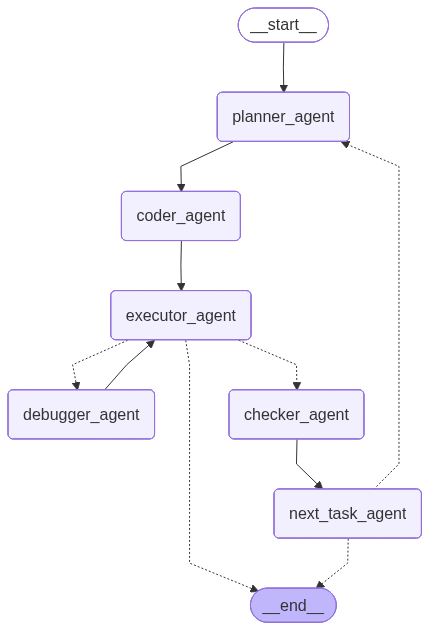

                                             +-----------+                                      
                                             | __start__ |                                      
                                             +-----------+                                      
                                                    *                                           
                                                    *                                           
                                                    *                                           
                                           +---------------+                                    
                                           | planner_agent |...                                 
                                           +---------------+   .......                          
                                            **                        .......                   
                              

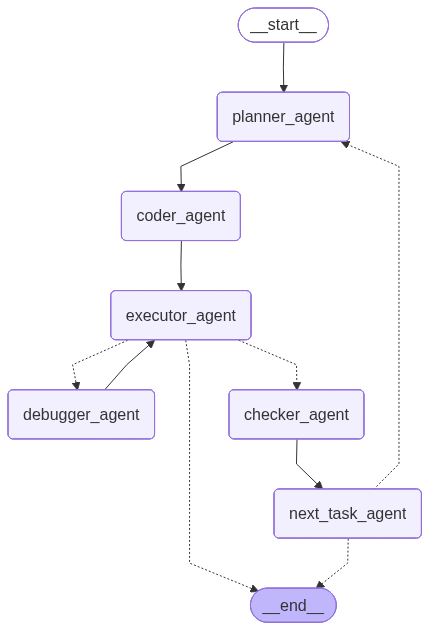

In [20]:
# =========================================================
# VISUALIZE GRAPH
# =========================================================

from IPython.display import (
    Image,
    display
)

graph_png = (
    graph.get_graph()
    .draw_mermaid_png()
)

display(Image(graph_png))

print(
    graph.get_graph().draw_ascii()
)
# Save image
with open("langgraph.png", "wb") as f:
    f.write(graph_png)

print("Graph image saved successfully!")

# Display image
display(Image(graph_png))


In [21]:
# =========================================================
# RUN GRAPH
# =========================================================

final_state = graph.invoke({

    "df": df,
    "tasks": PREPROCESSING_TASKS,
    "task_index": 0,
    "current_task": "",
    "generated_code": "",
    "preprocessing_output": "",
    "preprocessing_error": None,
    "retry_count": 0,
    "max_retries": 3,
    "debug_history": [],
    "last_error": ""
},
config={
    "recursion_limit": 100
})


PREPROCESSING TASK 1

Display dataset summary

GENERATED CODE

print("--- Dataset Info ---")                                                                                      
print(df.info())                                                                                                   
print("\n--- Descriptive Statistics ---")                                                                          
print(df.describe(include='all'))                                                                                  
print("\n--- Missing Values ---")                                                                                  
print(df.isnull().sum())                                                                                           
print("\n--- First 5 Rows ---")                                                                                    
print(df.head())                                                                                                   

╭─────────────────────────────────────────────── Execution Output ────────────────────────────────────────────────╮
│ --- Dataset Info ---                                                                                            │
│ <class 'pandas.DataFrame'>                                                                                      │
│ RangeIndex: 30 entries, 0 to 29                                                                                 │
│ Data columns (total 5 columns):                                                                                 │
│  #   Column         Non-Null Count  Dtype                                                                       │
│ ---  ------         --------------  -----                                                                       │
│  0   date           30 non-null     str                                                                         │
│  1   sku            30 non-null     str                                                                         │
│  2   location       30 non-null     str                                                                         │
│  3   quantity_sold  28 non-null     float64                                                                     │
│  4   inventory      30 non-null     int64                                                                       │
│ dtypes: float64(1), int64(1), str(3)                                                                            │
│ memory usage: 1.3 KB                                                                                            │
│ None                                                                                                            │
│                                                                                                                 │
│ --- Descriptive Statistics ---                                                                                  │
│               date      sku location  quantity_sold   inventory                                                 │
│ count           30       30       30      28.000000   30.000000                                                 │
│ unique          30        1        1            NaN         NaN                                                 │
│ top     2024-01-01  SKU_101  Chennai            NaN         NaN                                                 │
│ freq             1       30       30            NaN         NaN                                                 │
│ mean           NaN      NaN      NaN      81.964286   51.500000                                                 │
│ std            NaN      NaN      NaN      95.572537   38.799884                                                 │
│ min            NaN      NaN      NaN      -5.000000    0.000000                                                 │
│ 25%            NaN      NaN      NaN      55.750000   16.250000                                                 │
│ 50%            NaN      NaN      NaN      62.500000   47.500000                                                 │
│ 75%            NaN      NaN      NaN      69.250000   83.750000                                                 │
│ max            NaN      NaN      NaN     500.000000  120.000000                                                 │
│                                                                                                                 │
│ --- Missing Values ---                                                                                          │
│ date             0                                                                                              │
│ sku              0                                                                                              │
│ location         0                                                                                              │
│ quantity_sold    2                                    

...

Handle outliers using IQR only for numeric columns

GENERATED CODE

                                                                                                                   
import pandas as pd                                                                                                
import numpy as np                                                                                                 
                                                                                                                   
# Identify numeric columns                                                                                         
numeric_cols = df.select_dtypes(include=[np.number]).columns                                                       
                                                                                                                   
# Calculate IQR and handle outliers                                                                                
for col in numeric_cols:                                                                                           
    Q1 = df[col].quantile(0.25)                                                                                    
    Q3 = df[col].quantile(0.75)                                                                                    
    IQR = Q3 - Q1                                                                                                  
                                                                                                                   
    lower_bound = Q1 - 1.5 * IQR                                                                                   
    upper_bound = Q3 + 1.5 * IQR                                                                                   
                                                                                                                   
    # Count outliers before clipping                                                                               
    outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]                                
                                                                                                                   
    # Apply clipping to handle outliers                                                                            
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)                                                   
                                                                                                                   
    print(f"Column '{col}': Handled {outliers_count} outliers using IQR clipping.")                                
                                                                                                                   
print("\nOutlier handling complete. Dataframe updated.")                                                           
                                                                                                                   

╭─────────────────────────────────────────────── Execution Output ────────────────────────────────────────────────╮
│ Column 'quantity_sold': Handled 4 outliers using IQR clipping.                                                  │
│ Column 'inventory': Handled 0 outliers using IQR clipping.                                                      │
│                                                                                                                 │
│ Outlier handling complete. Dataframe updated.                                                                   │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

TASK COMPLETED SUCCESSFULLY

In [22]:
# =========================================================
# SAVE FINAL DATASET
# =========================================================

final_state["df"].to_csv(

    OUTPUT_DATASET,

    index=False
)

console.print(

    "\n[bold green]"
    "AUTONOMOUS PREPROCESSING PIPELINE COMPLETED"
    "[/bold green]"
)


AUTONOMOUS PREPROCESSING PIPELINE COMPLETED